In [1]:
import pandas as pd
import numpy as np

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load Feature Engineered Dataset
file_path = r"C:\Users\Admin\OneDrive\DataScience_Internship\Customer_Churn_Prediction\Telco_Churn_Feature_Engineered.csv"

df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,AvgMonthlySpend,HighMonthlyCharge,LongTermCustomer,AutoPayment
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,108.15,Yes,1,86,3239,Competitor made better offer,36.05,0,0,0
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,151.65,Yes,1,67,2701,Moved,50.55,1,0,0
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,820.50,Yes,1,86,5372,Moved,91.17,1,0,0
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,3046.05,Yes,1,84,5003,Moved,105.04,1,1,0
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,5036.30,Yes,1,89,5340,Competitor had better devices,100.73,1,1,1


In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Dataset information
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (7043, 37)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service 

In [4]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason', 'AvgMonthlySpend', 'HighMonthlyCharge', 'LongTermCustomer', 'AutoPayment']


In [6]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",     # Duplicate of target
    "Churn Reason"     # Data leakage
]

df.drop(columns=columns_to_drop, inplace=True)

print(df.shape)

(7043, 26)


In [7]:
X = df.drop("Churn Value", axis=1)

y = df["Churn Value"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 25)
Target: (7043,)


In [8]:
categorical_columns = X.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='str')


C:\Users\Admin\AppData\Local\Temp\ipykernel_53436\1948462041.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns


In [9]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print(X.shape)

(7043, 36)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 36)
(1409, 36)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
print(df[["Churn Value", "Churn Score", "CLTV"]].head())

   Churn Value  Churn Score  CLTV
0            1           86  3239
1            1           67  2701
2            1           86  5372
3            1           84  5003
4            1           89  5340


In [13]:
# Columns to remove
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

# Drop only columns that exist
df.drop(columns=[col for col in columns_to_drop if col in df.columns],
        inplace=True)

print(df.shape)
print(df.columns)

(7043, 24)
Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'AvgMonthlySpend', 'HighMonthlyCharge', 'LongTermCustomer',
       'AutoPayment'],
      dtype='str')


In [14]:
# Features
X = df.drop("Churn Value", axis=1)

# Target
y = df["Churn Value"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7043, 23)
y Shape: (7043,)


In [15]:
# Find categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='str')


C:\Users\Admin\AppData\Local\Temp\ipykernel_53436\1674529688.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns


In [16]:
# One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after encoding:", X.shape)

Shape after encoding: (7043, 34)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (5634, 34)
Testing : (1409, 34)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
lr_model = LogisticRegression(random_state=42)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.808374733853797

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:

[[925 110]
 [160 214]]


In [20]:
from sklearn.tree import DecisionTreeClassifier

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.723207948899929

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1035
           1       0.48      0.50      0.49       374

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.73      1409


Confusion Matrix:

[[832 203]
 [187 187]]


In [21]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7877927608232789

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:

[[923 112]
 [187 187]]


In [22]:
pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 2.1 MB/s eta 0:00:33
   ---------------------------------------- 0.8/69.5 MB 1.6 MB/s eta 0:00:44
    --------------------------------------- 1.0/69.5 MB 1.4 MB/s eta 0:00:49
    --------------------------------------- 1.6/69.5 MB 1.7 MB/s eta 0:00:41
   - -------------------------------------- 2.1/69.5 MB 1.9 MB/s eta 0:00:37
   - -------------------------------------- 2.6/69.5 MB 2.0 MB/s eta 0:00:35
   - -------------------------------------- 3.1/69.5 MB 2.1 MB/s eta 0:00:33
   -- ------------------------------------- 3.9/69.5 MB 2.2 MB/s eta 0:00:31
   -- ------------------------------------- 4.5/69.5 MB 2.2 MB/s eta 0:00:30
   -- ---------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from xgboost import XGBClassifier

# Create model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7913413768630234

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.79      0.79      0.79      1409


Confusion Matrix:

[[907 128]
 [166 208]]


In [24]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

print(results)

                 Model  Accuracy
0  Logistic Regression  0.808375
3              XGBoost  0.791341
2        Random Forest  0.787793
1        Decision Tree  0.723208


In [25]:
import joblib

joblib.dump(rf_model, "Customer_Churn_Model.pkl")

print("Model saved successfully!")

Model saved successfully!


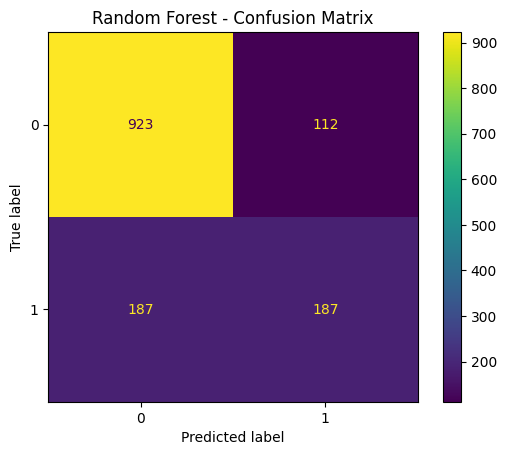

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)

plt.title("Random Forest - Confusion Matrix")
plt.show()

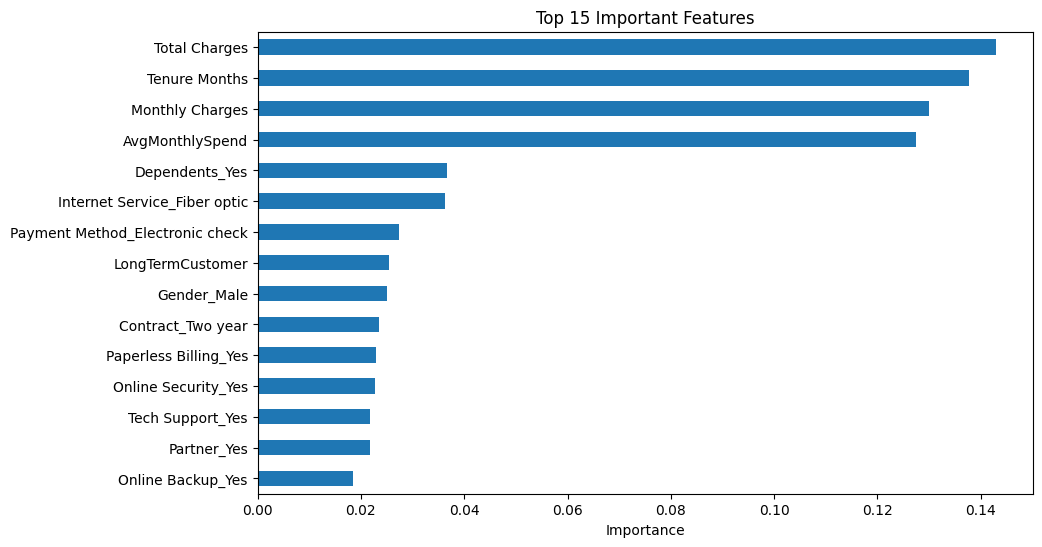

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.head(15).plot(kind="barh")
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [28]:
from sklearn.metrics import roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.8281123252990261


In [29]:
print(results)

                 Model  Accuracy
0  Logistic Regression  0.808375
3              XGBoost  0.791341
2        Random Forest  0.787793
1        Decision Tree  0.723208


In [30]:
from sklearn.metrics import roc_auc_score

# Logistic Regression
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])

# Decision Tree
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])

# Random Forest
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

# XGBoost
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

print("Logistic Regression AUC:", lr_auc)
print("Decision Tree AUC:", dt_auc)
print("Random Forest AUC:", rf_auc)
print("XGBoost AUC:", xgb_auc)

Logistic Regression AUC: 0.8524451677904363
Decision Tree AUC: 0.6514492753623189
Random Forest AUC: 0.8281123252990261
XGBoost AUC: 0.8372807357462089
